In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

plt.style.use('default')

## **Problem 1 to 2:**

**Dataset link:** https://rb.gy/gsmddu

**Add a label to every axis and add a proper title for the charts (For every subplot, it is applicable). Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

### **Problem-1:** Make a subplots which have 2 plots.

- For the first chart, draw a scatter plot "*Monitored Cap.(MW)*" vs "*Total Cap. Under Maintenance (MW)*" of top 5 most frequent power stations. Then draw the lines which indicate the average values of these two columns. Change the colors according to the names of the Power Stations.
- For the second chart, draw a scatter plot "*Monitored Cap. (MW)*" vs "*Actual(MU)*" of the top 5 most frequent power stations. Also draw the lines which indicates the average values of these two columns. Change the colors according to the names of the Power Stations.


In [2]:
# code here
df = pd.read_csv("PowerGeneration - PowerGeneration.csv")
df.head()

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0


In [3]:
df.shape

(345273, 11)

In [4]:
most_freq = df['Power Station'].value_counts().head().index.tolist()
# Filter data for only these top 5 stations
temp_df = df[df['Power Station'].isin(most_freq)]
temp_df_name = temp_df.copy()

temp_df_name

In [5]:
temp_df_name['Power Station'].value_counts()

Power Station
NTPC Ltd.    9570
NHPC         5742
NPCIL        5742
GMR ENERG    5742
APL          3828
Name: count, dtype: int64

In [6]:
temp_df['Power Station'].value_counts()

Power Station
NTPC Ltd.    9570
NHPC         5742
NPCIL        5742
GMR ENERG    5742
APL          3828
Name: count, dtype: int64

this will change the names to   
APL-->1,  
NPCIL--> 2   

In [7]:
encoder = LabelEncoder()
temp_df['Power Station'] = encoder.fit_transform(temp_df['Power Station'])

In [8]:
temp_df_name['Power Station'].values

<ArrowStringArray>
[      'APL',      'NHPC',     'NPCIL', 'NTPC Ltd.',       'APL', 'GMR ENERG',
     'NPCIL', 'NTPC Ltd.', 'GMR ENERG',     'NPCIL',
 ...
     'NPCIL', 'NTPC Ltd.', 'GMR ENERG',     'NPCIL', 'NTPC Ltd.', 'GMR ENERG',
      'NHPC', 'NTPC Ltd.',      'NHPC', 'NTPC Ltd.']
Length: 30624, dtype: str

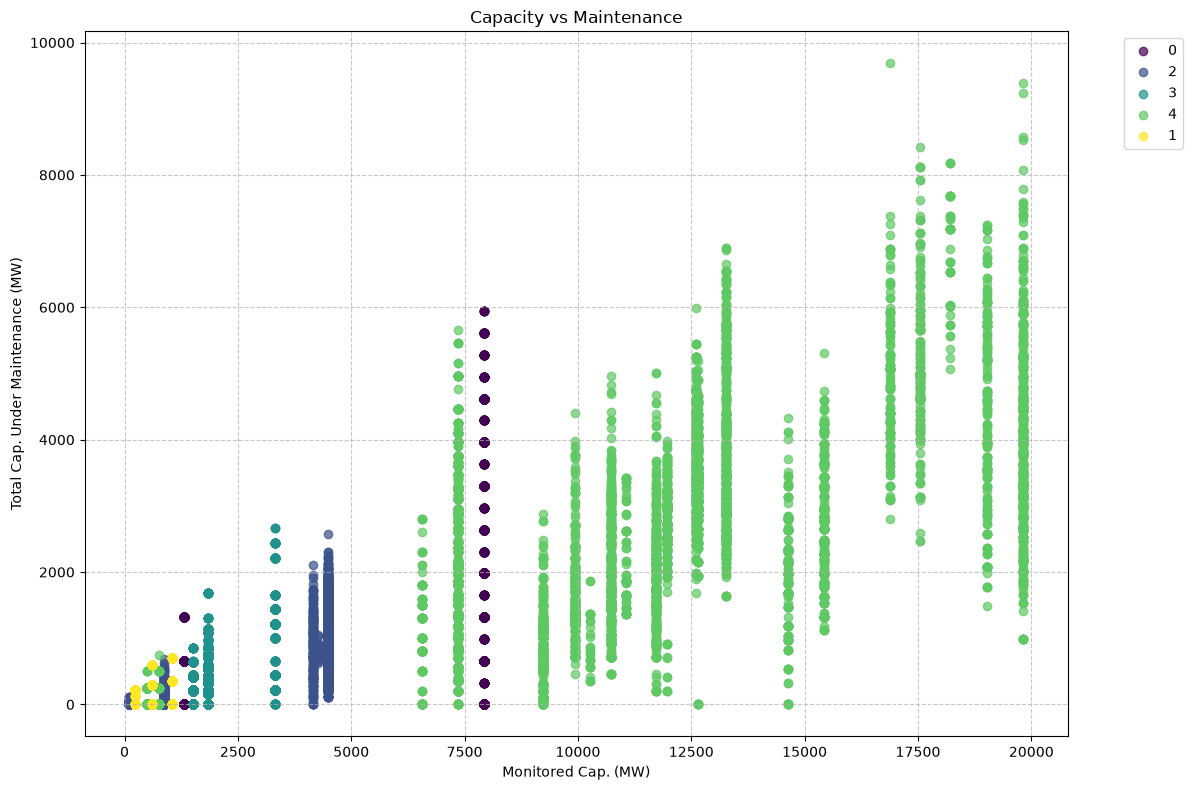

In [9]:
# Create figure
plt.figure(figsize=(12, 8))

# Scatter plot with colors mapped to station names
stations = temp_df["Power Station"].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(stations)))
station_colors = {station: colors[i] for i, station in enumerate(stations)}

for station in stations:
    subset = temp_df[temp_df["Power Station"] == station]
    plt.scatter(subset["Monitored Cap.(MW)"], 
                subset["Total Cap. Under Maintenace (MW)"],
                c=[station_colors[station]], 
                label=station, alpha=0.7)



plt.xlabel("Monitored Cap. (MW)")
plt.ylabel("Total Cap. Under Maintenance (MW)")
plt.title("Capacity vs Maintenance")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

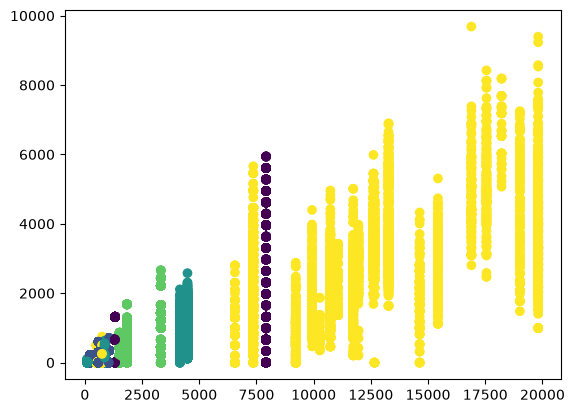

In [10]:

plt.scatter(temp_df["Monitored Cap.(MW)"], temp_df["Total Cap. Under Maintenace (MW)"],c= temp_df["Power Station"])
# for i in range(temp_df.shape[0]):
#     plt.text(temp_df["Monitored Cap.(MW)"].values[i],temp_df["Total Cap. Under Maintenace (MW)"].values[i],#temp_df_name['Power Station'].values[i]
#            )


- For the second chart, draw a scatter plot "*Monitored Cap. (MW)*" vs "*Actual(MU)*" of the top 5 most frequent power stations. Also draw the lines which indicates the average values of these two columns. Change the colors according to the names of the Power Stations.

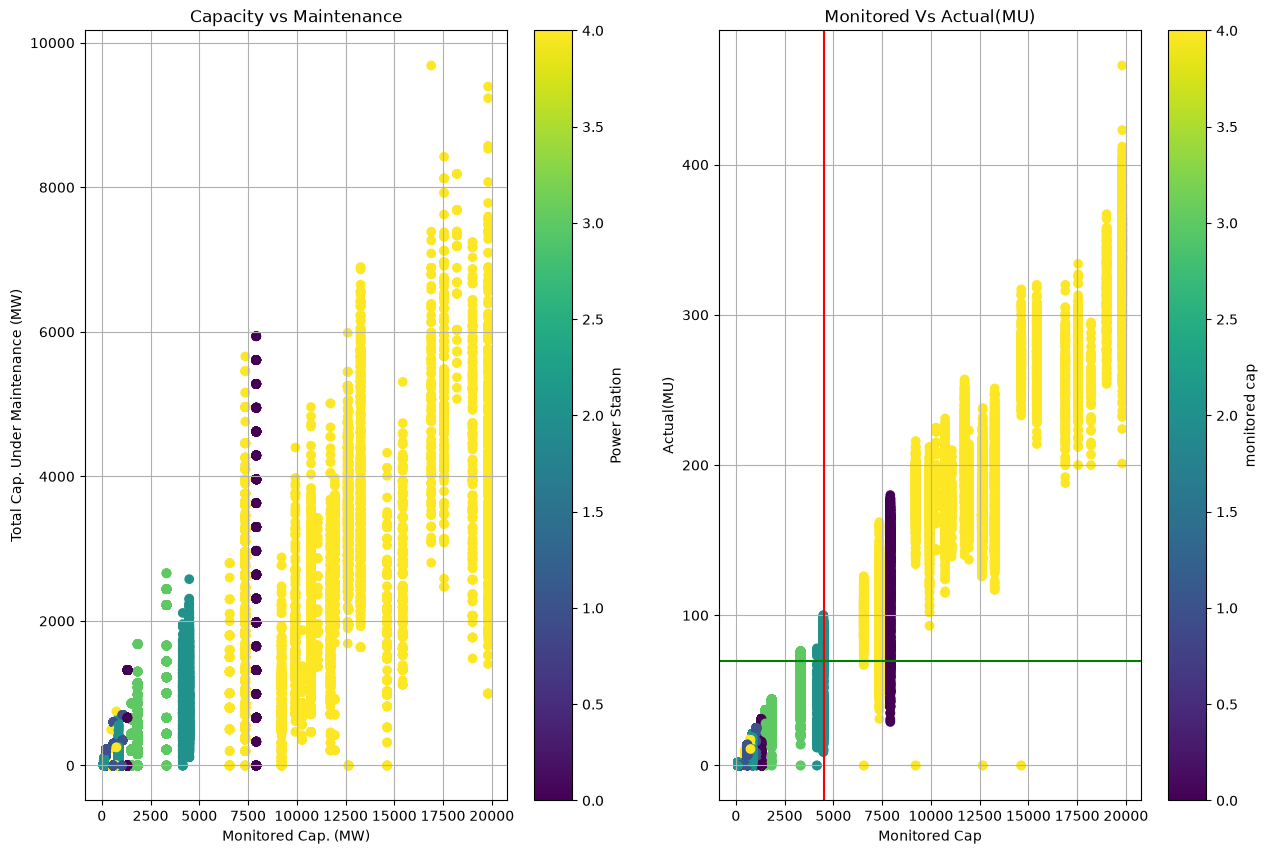

In [11]:
fig, ax = plt.subplots(1,2,figsize=(15,10))

cc=ax[0].scatter(temp_df["Monitored Cap.(MW)"], temp_df["Total Cap. Under Maintenace (MW)"],c= temp_df["Power Station"],)
ax[0].set_xlabel("Monitored Cap. (MW)")
ax[0].set_ylabel("Total Cap. Under Maintenance (MW)")
ax[0].set_title("Capacity vs Maintenance")
plt.colorbar(cc, ax=ax[0], label='Power Station')
ax[0].grid(True)   

bbc= ax[1].scatter(temp_df["Monitored Cap.(MW)"],temp_df["Actual(MU)"],c= temp_df["Power Station"])
ax[1].set_xlabel("Monitored Cap")
ax[1].set_ylabel("Actual(MU)")
ax[1].set_title('Monitored Vs Actual(MU)')
ax[1].grid(True)
ax[1].axvline(temp_df['Monitored Cap.(MW)'].mean(),c='red')
ax[1].axhline(temp_df['Actual(MU)'].mean(),c='green')
plt.colorbar(bbc, ax= ax[1],label="monitored cap")

In [12]:
df.head()

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0


### **Problem-2:** Draw a 3D Scatter plot between "*Monitored Cap.(MW)*", "*Total Cap. Under Maintenace (MW)*" and "*Forced Maintanence(MW)*"

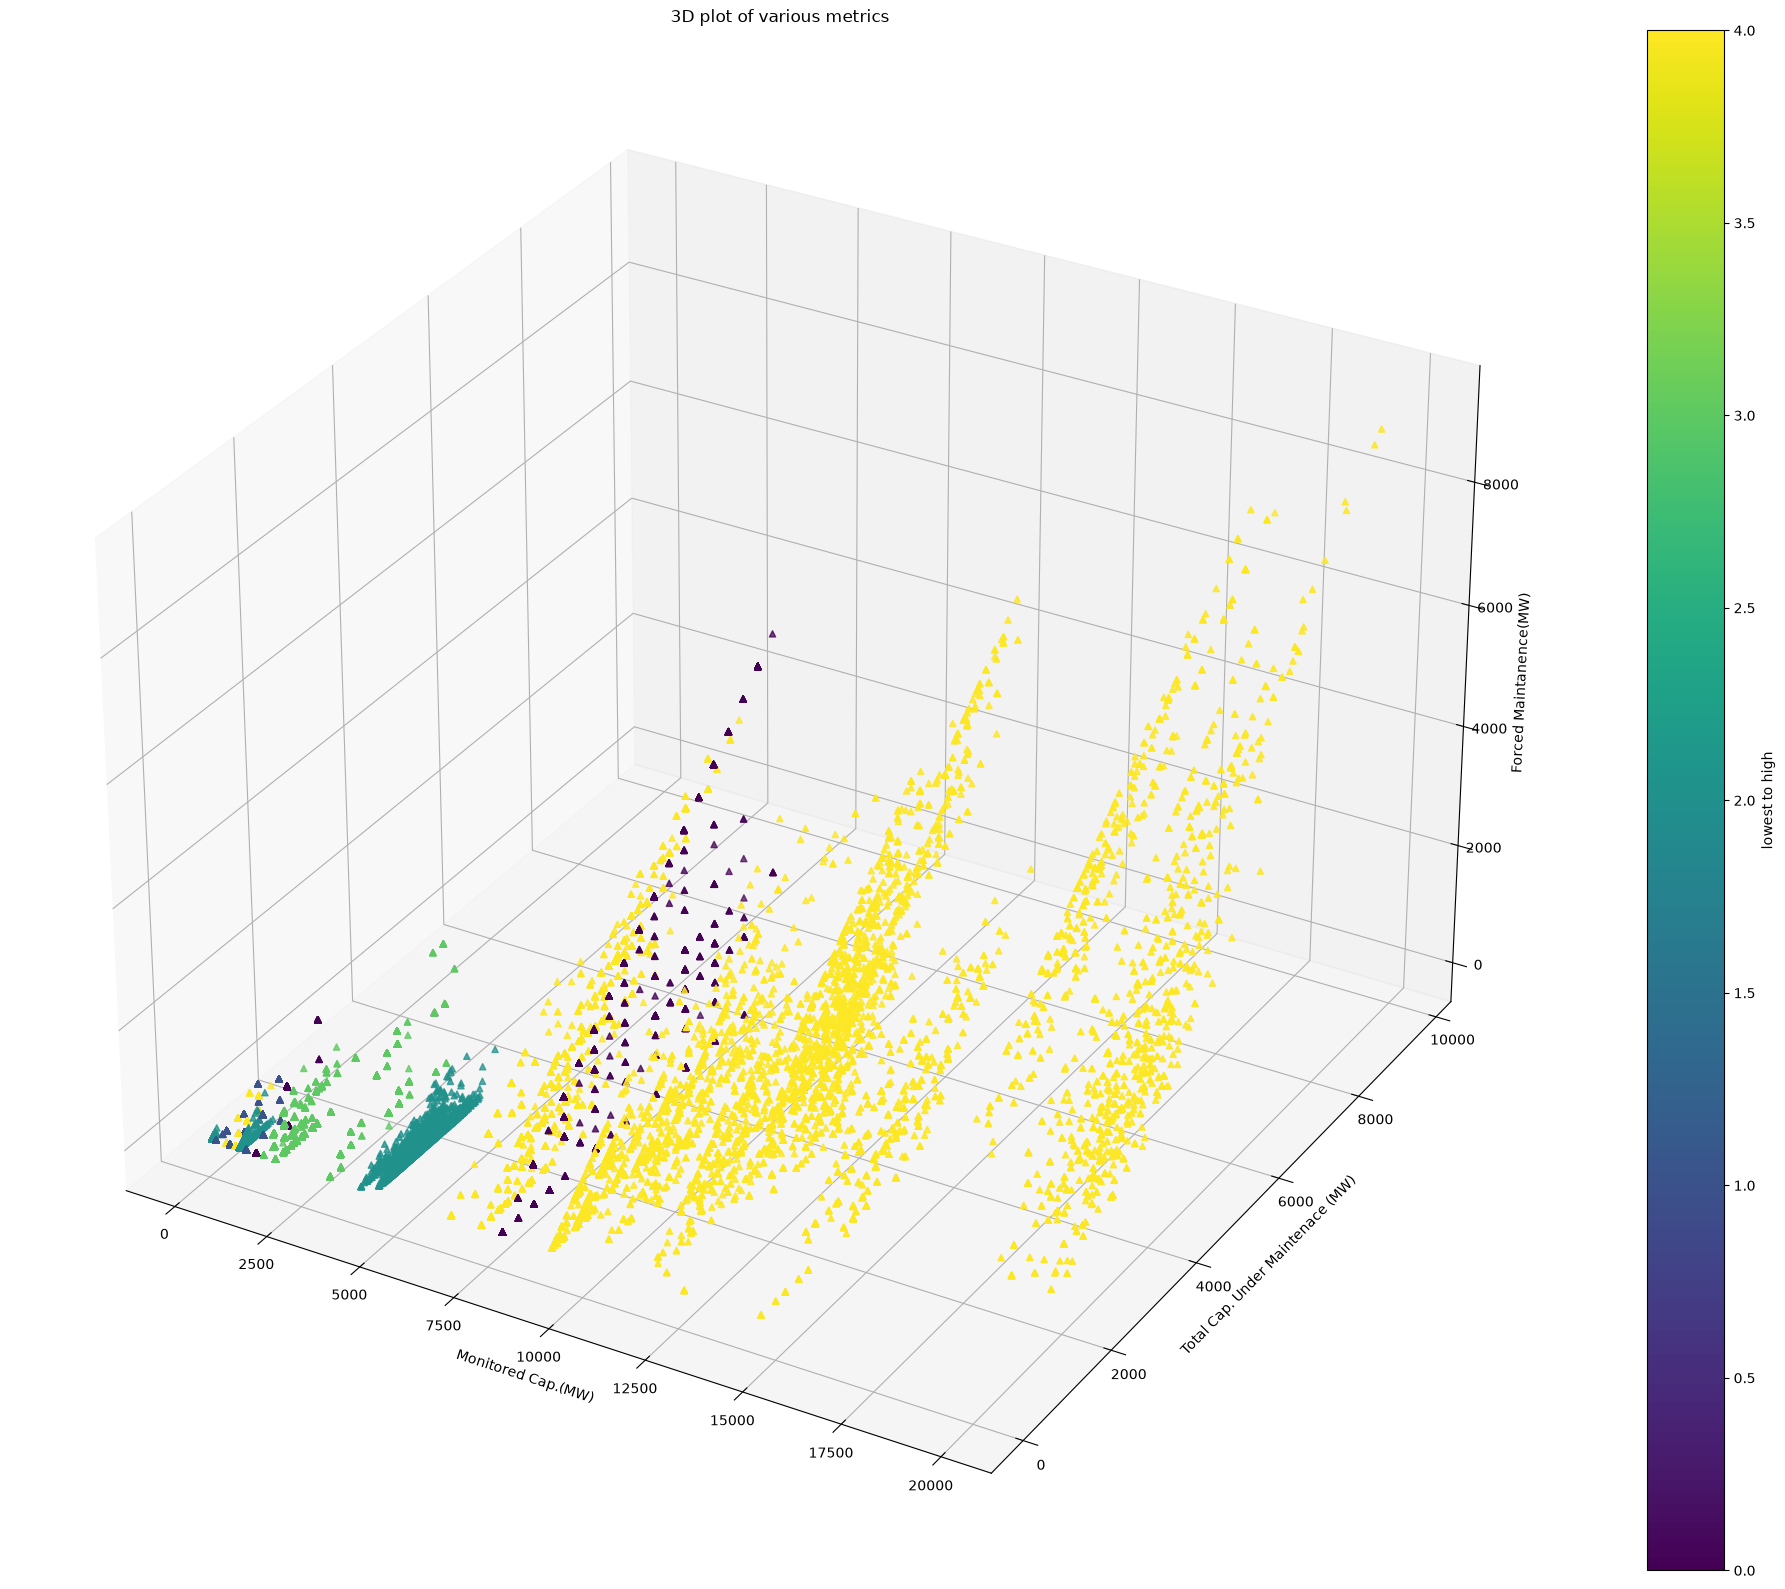

In [13]:

fig = plt.figure(figsize=(25, 20))
ax = fig.add_subplot(111, projection='3d')
bb=ax.scatter3D(temp_df["Monitored Cap.(MW)"], temp_df["Total Cap. Under Maintenace (MW)"], temp_df["Forced Maintanence(MW)"], c=temp_df['Power Station'],marker="^")
ax.set_xlabel('Monitored Cap.(MW)')
ax.set_ylabel('Total Cap. Under Maintenace (MW)')
ax.set_zlabel('Forced Maintanence(MW)')
ax.set_title('3D plot of various metrics')


plt.colorbar(bb, ax= ax,label="lowest to high")

C:\Users\manis\AppData\Local\Temp\ipykernel_25124\3037027442.py:24: UserWarning: Mismatched number of handles and labels: len(handles) = 6 len(labels) = 5
  ax.legend(handles, uniques, title="Power Station", loc='center left', bbox_to_anchor=(1.05, 0.5))


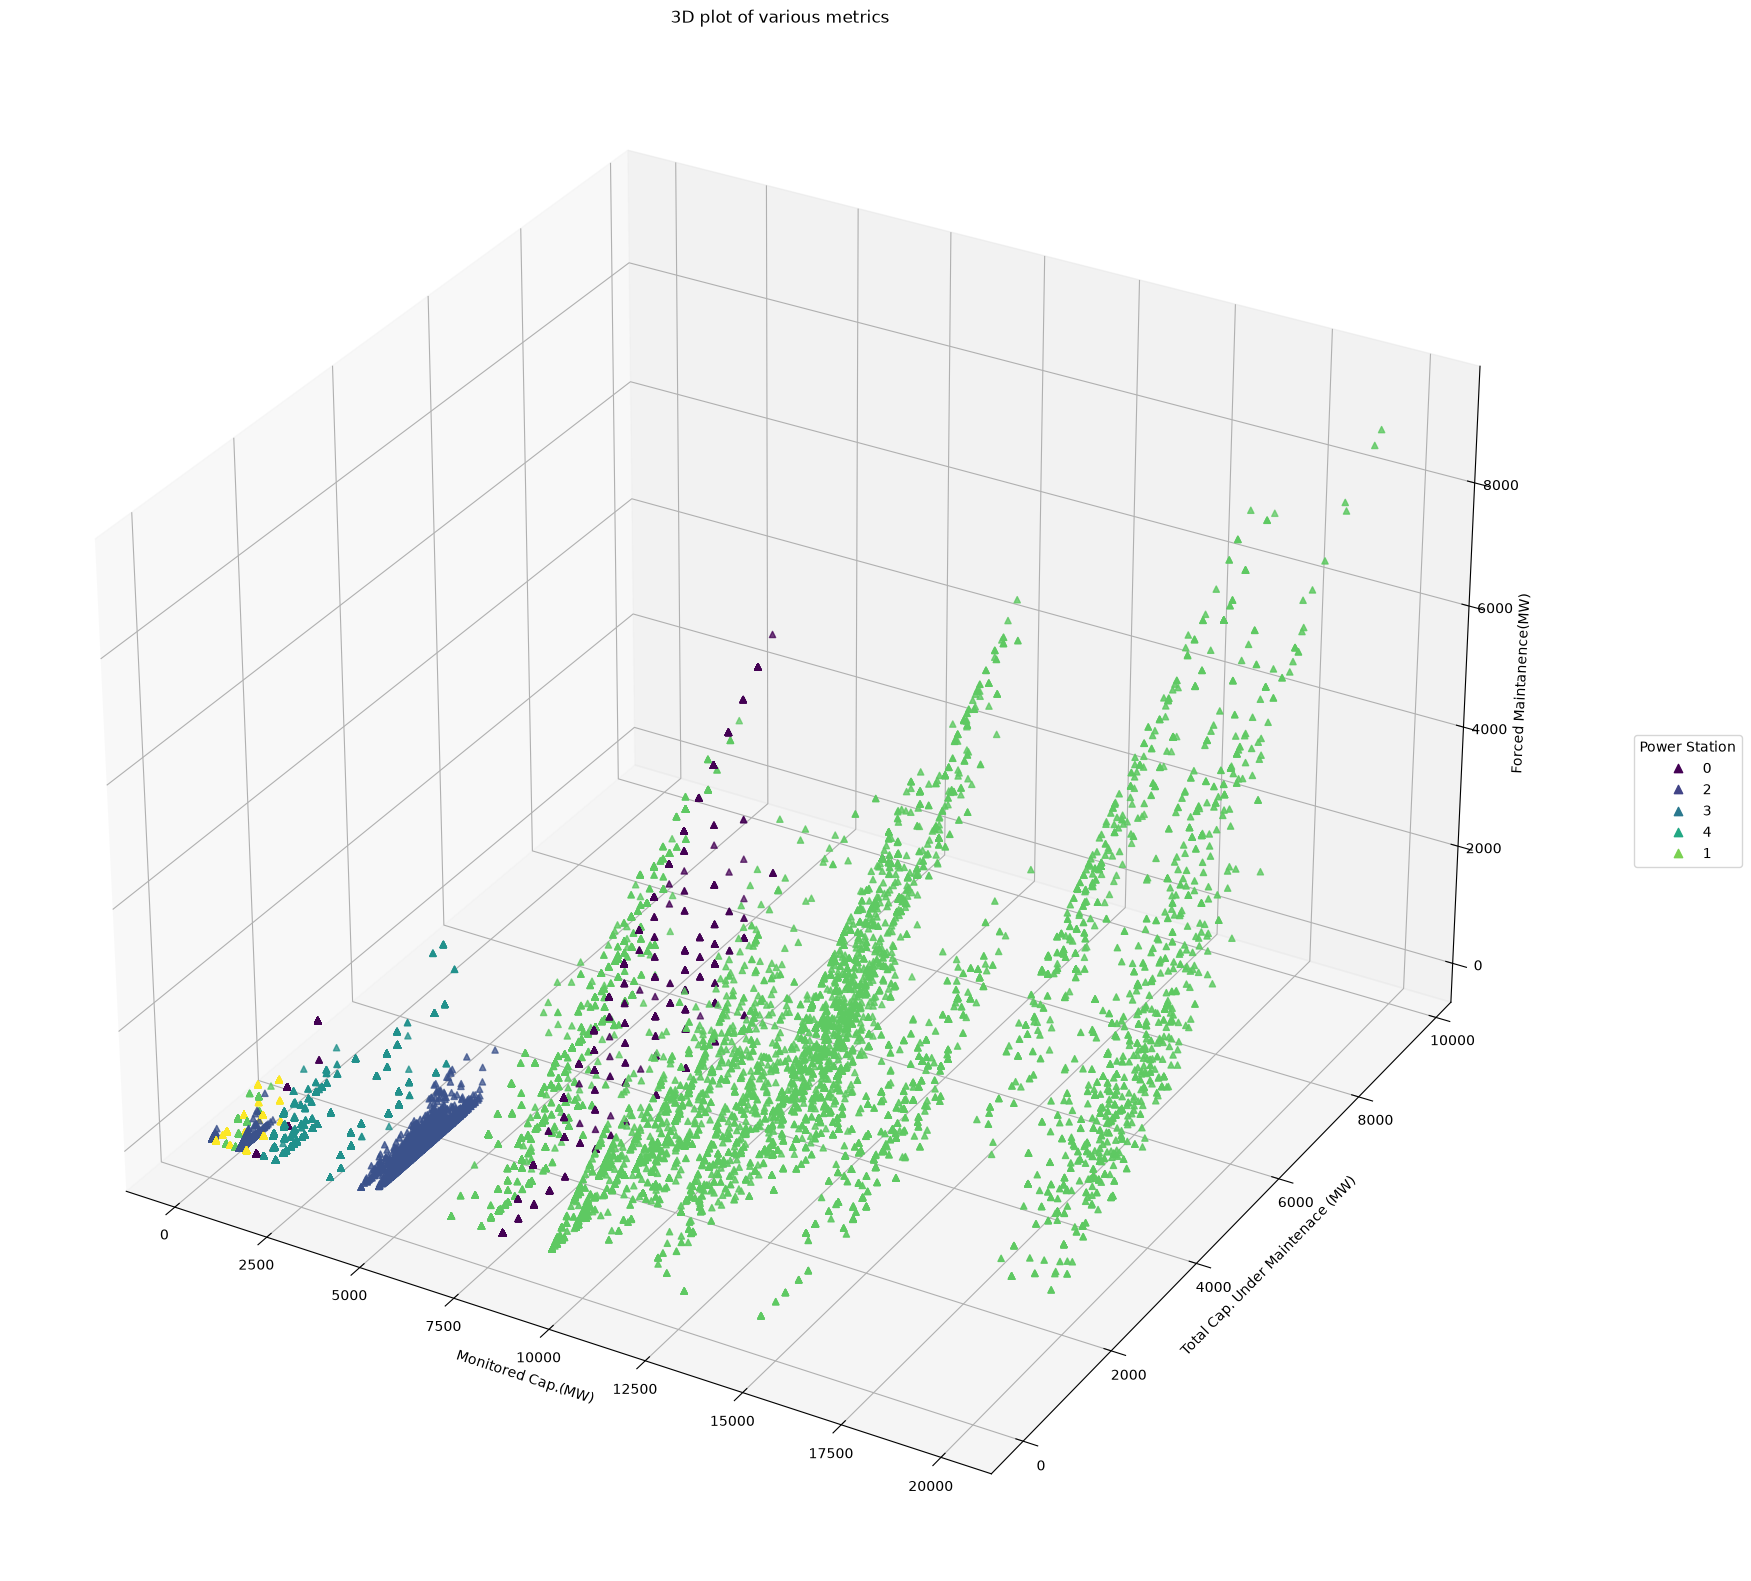

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig = plt.figure(figsize=(25, 20))
ax = fig.add_subplot(111, projection='3d')

# Encode categories as integer codes for coloring
codes, uniques = pd.factorize(temp_df['Power Station'])

bb = ax.scatter3D(temp_df["Monitored Cap.(MW)"], 
                   temp_df["Total Cap. Under Maintenace (MW)"], 
                   temp_df["Forced Maintanence(MW)"], 
                   c=codes, 
                   cmap='viridis',
                   marker="^")

ax.set_xlabel('Monitored Cap.(MW)')
ax.set_ylabel('Total Cap. Under Maintenace (MW)')
ax.set_zlabel('Forced Maintanence(MW)')
ax.set_title('3D plot of various metrics')

# Build legend handles from the scatter's colors, but relabel with actual names
handles, _ = bb.legend_elements(num=len(uniques))
ax.legend(handles, uniques, title="Power Station", loc='center left', bbox_to_anchor=(1.05, 0.5))

plt.show()

### **Problem-3:** Make a 3D *Surface* plot of this below mathematical equation.

$$z = |x| - |y|$$

In [16]:

x=abs(int(input("Enter the value of x ")))
print(x)

ValueError: invalid literal for int() with base 10: ''

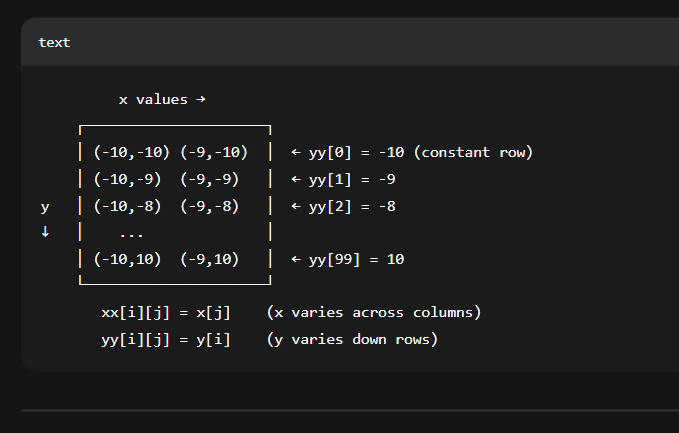

In [15]:
# code here
x= np.linspace(-10,10,100)
y= np.linspace(-10,10,100)
xx, yy, = np.meshgrid(x,y) 

z = np.abs(xx) - np.abs(yy)


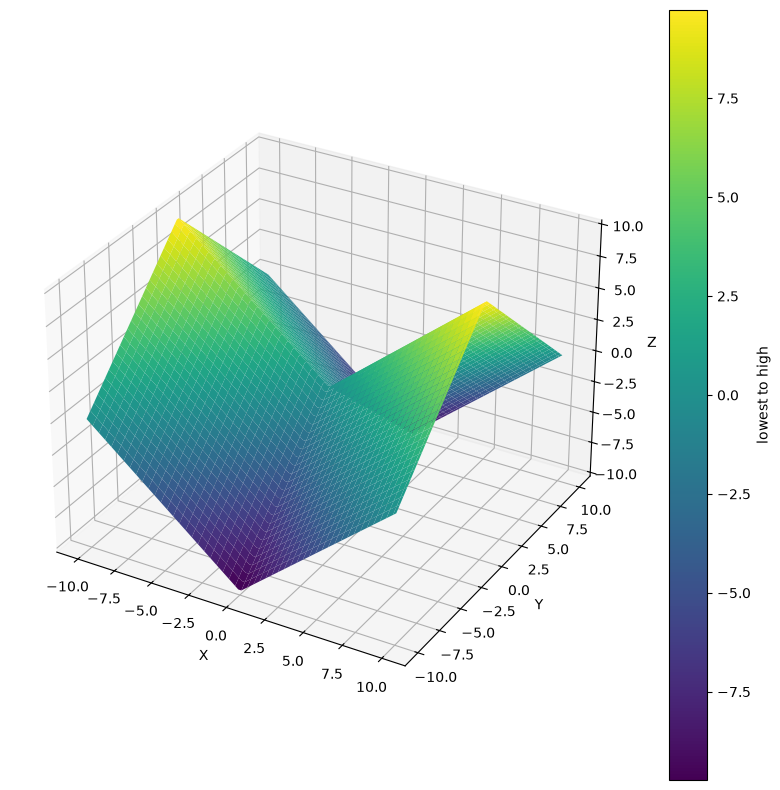

In [16]:
fig = plt.figure(figsize=(10,10))
ax = plt.subplot(projection = "3d")

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')


p= ax.plot_surface(xx,yy,z , cmap= "viridis")

plt.colorbar(p, ax= ax,  label="lowest to high")

### **Problem-4:** Draw the 3D *Contour plot* of this below equation:

$$z = |x| - |y|$$

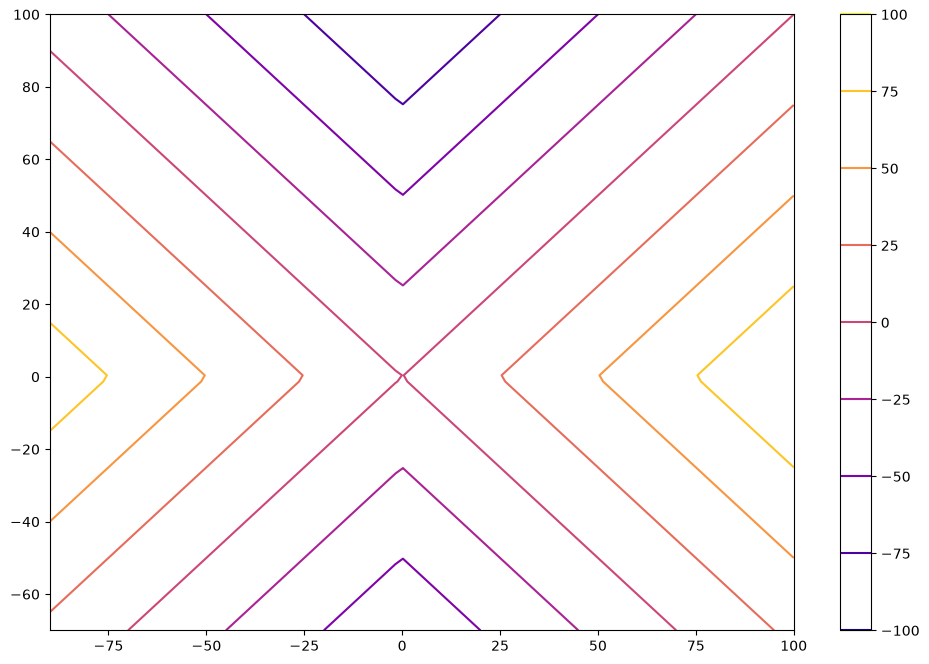

In [17]:
# code here
x = np.linspace(-90,100,100)
y = np.linspace(-70,100,100)

xx,yy = np.meshgrid(x,y)
z = np.abs(xx) - np.abs(yy)


fig = plt.figure(figsize= (12,8))
ax= plt.subplot()
p= ax.contour(xx,yy,z, cmap = "plasma")

fig.colorbar(p)


### **Problem-5:** Draw a second type of Countour plot of the below equation:

$$z = |x| - |y|$$

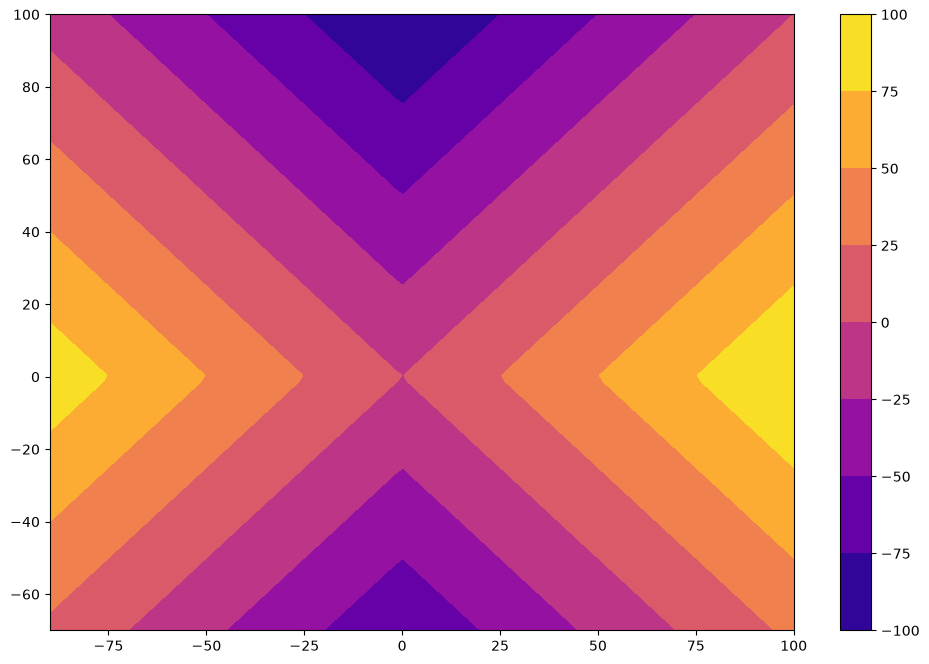

In [18]:
# code here


# code here
x = np.linspace(-90,100,100)
y = np.linspace(-70,100,100)

xx,yy = np.meshgrid(x,y)
z = np.abs(xx) - np.abs(yy)


fig = plt.figure(figsize= (12,8))
ax= plt.subplot()
p= ax.contourf(xx,yy,z, cmap = "plasma")

fig.colorbar(p)


## `Problem 6-7`

Data Set Link - https://docs.google.com/spreadsheets/d/17tUL2yC7MGvo7txuuhLtAI-b6_C4jc0t7FLFxqRm-uI/edit?usp=share_link


**Description of Dataset:**

* Date: It gives the date of which stocks details are given.
* Symbol: Name of stock
* Open: It gives the opening price of stock on that date.
* High: It gives the highest price to which the stock ascened on that day.
* Low: It gives the highest price to which the stock plummeted on that day.
* Close: It gives the closing price of stock on that date.
* Volume: It gives the amount of stock traded on that date.
* VWAP: The volume-weighted average price (VWAP) is a statistic used by traders to determine what the average price is based on both price and volume.
* Turnover:

### `Problem-6` Use Pandas plot functions

* Line plot of closing value of top 5 Stocks in Year 2020.
* Take top 5 stocks based on total turnover in Year 2020

In [51]:
nifty = pd.read_csv('nifty-50.csv')
nifty.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades
0,2000-01-03,HDFCBANK,EQ,157.40,166.00,170.00,166.00,170.00,170.00,169.52,33259,5.638120e+11,NaN
1,2000-01-04,HDFCBANK,EQ,170.00,182.00,183.45,171.00,174.00,173.80,174.99,168710,2.952260e+12,NaN
2,2000-01-05,HDFCBANK,EQ,173.80,170.00,173.90,165.00,168.00,166.95,169.20,159820,2.704090e+12,NaN
3,2000-01-06,HDFCBANK,EQ,166.95,168.00,170.00,165.30,168.95,168.30,168.44,85026,1.432170e+12,NaN
4,2000-01-07,HDFCBANK,EQ,168.30,162.15,171.00,162.15,170.75,168.35,166.79,85144,1.420160e+12,NaN


In [52]:
# code here
nifty['Date'] = pd.to_datetime(nifty['Date'])

In [53]:
nifty.set_index('Date',inplace=True)

In [54]:
temp_df = nifty[nifty.index.year == 2020]

In [55]:
top_5 = temp_df.groupby('Symbol')['Turnover'].sum().sort_values(ascending=False).head().index

In [56]:
tempm_df = temp_df[temp_df['Symbol'].isin(top_5)]

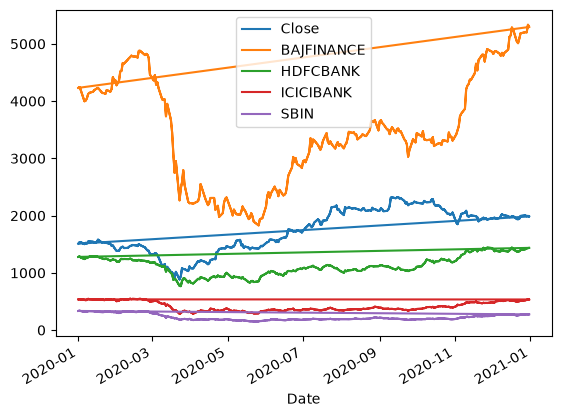

In [57]:
ax = temp_df[temp_df.Symbol=='RELIANCE'].plot(y='Close', use_index=True)

for company in top_5[1:]:
    temp_df[temp_df.Symbol==company].plot(y='Close', label=company, use_index=True, ax=ax)

### `Problem-7` Scatter plot Close price vs Volume for TOP-5 Stocks in year 2021
* Color on Symbol Column

In [58]:
temp_df = nifty[nifty.index.year == 2021]

In [60]:
top_5 = temp_df.groupby('Symbol')['Turnover'].sum().sort_values(ascending=False).head().index
tempm_df = temp_df[temp_df['Symbol'].isin(top_5)]

In [61]:
tempm_df

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades
Date,,,,,,,,,,,,
2021-01-01,HDFCBANK,EQ,1436.30,1440.00,1443.00,1420.60,1423.45,1425.05,1433.57,4405469,6.315530e+14,85415.0
2021-01-04,HDFCBANK,EQ,1425.05,1438.00,1438.00,1399.00,1422.25,1416.00,1417.20,7870096,1.115350e+15,177576.0
2021-01-05,HDFCBANK,EQ,1416.00,1419.20,1430.75,1409.00,1425.85,1426.70,1419.93,7193412,1.021420e+15,186611.0
2021-01-06,HDFCBANK,EQ,1426.70,1435.00,1440.00,1413.10,1419.80,1420.55,1423.55,11067025,1.575450e+15,151854.0
2021-01-07,HDFCBANK,EQ,1420.55,1432.50,1432.60,1412.55,1416.90,1416.25,1422.34,9947421,1.414860e+15,127305.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-26,SBIN,EQ,336.45,339.25,347.45,339.25,344.80,344.30,345.26,49234985,1.699870e+15,306217.0
2021-04-27,SBIN,EQ,344.30,344.00,354.95,342.40,354.20,353.05,349.42,46003023,1.607460e+15,293357.0
2021-04-28,SBIN,EQ,353.05,357.00,364.30,356.05,362.90,363.40,361.63,56696255,2.050310e+15,337002.0



# astype('category') 
converts a column to categorical data type.

<Axes: xlabel='Close', ylabel='Volume'>

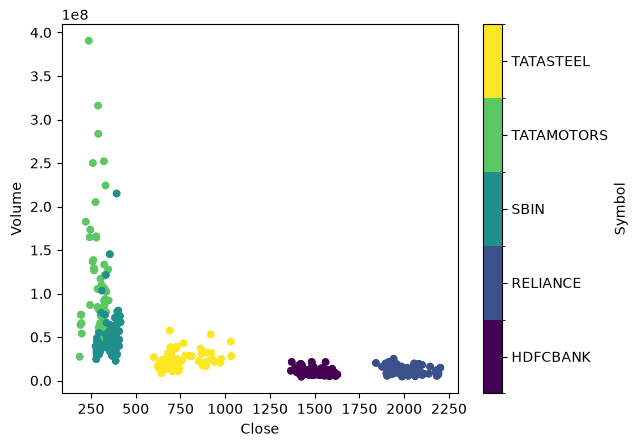

In [65]:
# code here
temp_df = nifty[nifty.index.year == 2021]
top_5 = temp_df.groupby('Symbol')['Turnover'].sum().sort_values(ascending=False).head().index
temp_df = temp_df[temp_df['Symbol'].isin(top_5)]

temp_df['Symbol'] = temp_df['Symbol'].astype('category')
temp_df.plot(kind='scatter', x='Close', y='Volume', c='Symbol', colormap='viridis')

### `Problem-8` Create a 3-D Scatter Plot using `time,x,y` on below synthetic data. and give color gradiant on `z`
```
# Create a 3D dataset
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

# Create a DataFrame from the dataset
data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})
```

In [25]:
# code here

### `Problem 9:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = sin(\sqrt{x^2 + y^2})$$


In [ ]:
# code here

### `Problem 10:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = tan(\log_2({x^2 + y^2})$$

In [ ]:
# code here